In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
# Load data
house = pd.read_csv("house_price.csv")


In [3]:
# Prepare data (simplified)
X = house[['Size', 'Bedrooms', 'Age']].fillna(house[['Size', 'Bedrooms', 'Age']].median())
y = house['Price']

# Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Train Baseline
model = LinearRegression()
model.fit(X_train, y_train)

print("Training R²:", model.score(X_train, y_train))
print("Testing R²:", model.score(X_test, y_test))

Training R²: 0.9651766710777244
Testing R²: 0.9595027479329997


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²  : {r2:.3f}")

MAE : ₹50,245.03
RMSE: ₹58,403.59
R²  : 0.960


In [5]:
# 7. Print Results
print(f"MAE : ₹{mae:,.2f}")
print(f"MSE : ₹{mse:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²  : {r2:.3f}")

# 8. Quick Interpretation
print("\n--- Interpretation ---")
print(f"The model explains {r2*100:.1f}% of the variance in house prices.")
print(f"On average, predictions are off by ₹{mae:,.0f}.")
print(f"The RMSE is ₹{rmse:,.0f}, which penalizes larger errors more heavily.")

MAE : ₹50,245.03
MSE : ₹3,410,978,823.61
RMSE: ₹58,403.59
R²  : 0.960

--- Interpretation ---
The model explains 96.0% of the variance in house prices.
On average, predictions are off by ₹50,245.
The RMSE is ₹58,404, which penalizes larger errors more heavily.


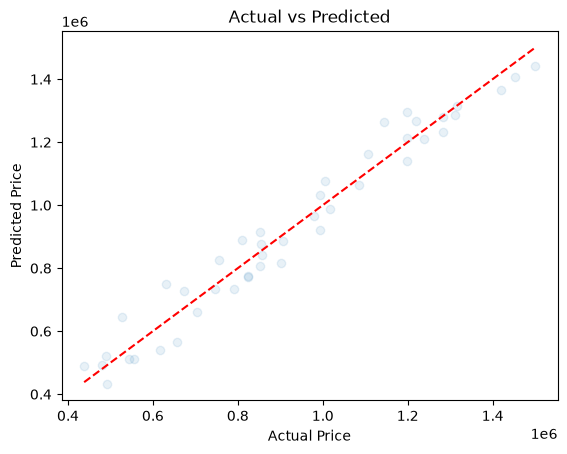

In [9]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [13]:
Advanced Improvement and testing all other methods

SyntaxError: invalid syntax (3219425416.py, line 1)

In [12]:
import pandas as pd
import numpy as np

# Load data
house = pd.read_csv("house_price.csv")

# --- Feature Engineering ---
# 1. Fill missing values first
house['Bedrooms'] = house['Bedrooms'].fillna(house['Bedrooms'].median())
house['Age'] = house['Age'].fillna(house['Age'].median())
house['Location'] = house['Location'].fillna(house['Location'].mode()[0])

# 2. Create new features
house['Size_per_Bedroom'] = house['Size'] / house['Bedrooms']
house['Age_Group'] = pd.cut(house['Age'], bins=[0, 10, 30, 100], labels=['New', 'Medium', 'Old'])
house['Is_Urban'] = house['Location'].map({'Urban': 1, 'Rural': 0})

# 3. Handle categorical variables (One-Hot Encoding)
house = pd.get_dummies(house, columns=['Location', 'Age_Group'], drop_first=True)

print("New columns created:")
print(house.columns.tolist())
print("\nSample data:")
display(house.head())

New columns created:
['Size', 'Bedrooms', 'Age', 'Price', 'Size_per_Bedroom', 'Is_Urban', 'Location_Urban', 'Age_Group_Medium', 'Age_Group_Old']

Sample data:


,Size,Bedrooms,Age,Price,Size_per_Bedroom,Is_Urban,Location_Urban,Age_Group_Medium,Age_Group_Old
0,859,1.0,2.0,586315,859.0,1,True,False,False
1,2469,3.0,26.0,1233388,823.0,1,True,True,False
2,2188,4.0,13.0,1069161,547.0,0,False,True,False
3,1681,2.0,4.0,830750,840.5,0,False,False,False
4,1668,4.0,25.0,928932,417.0,1,True,True,False


In [15]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [16]:
# Prepare X and y (using engineered features)
X = house.drop(columns=['Price'])
y = house['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [17]:
# Define models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1000, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
}

In [18]:
try:
    from xgboost import XGBRegressor
    models['XGBoost'] = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=0.8, random_state=42)
    print("XGBoost added to comparison.")
except ImportError:
    print("XGBoost not installed. Skipping.")

XGBoost not installed. Skipping.


In [19]:
# Train and evaluate each model
results = []

for name, model in models.items():
    # Create pipeline with imputation
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    y_pred = pipe.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Calculate MAPE
    non_zero = y_test != 0
    mape = np.mean(np.abs((y_test[non_zero] - y_pred[non_zero]) / y_test[non_zero])) * 100
    
    results.append({
        'Model': name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R²': round(r2, 4),
        'MAPE (%)': round(mape, 2)
    })

# Display comparison table
results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n--- Model Comparison ---")
display(results_df)


--- Model Comparison ---


,Model,MAE,RMSE,R²,MAPE (%)
0,Linear Regression,27682.09,36337.87,0.9843,3.59
1,Ridge Regression,27759.16,36479.54,0.9842,3.60
2,Lasso Regression,28174.44,37316.06,0.9835,3.65
4,Gradient Boosting,36513.99,45063.40,0.9759,4.86
3,Random Forest,44773.27,57757.10,0.9604,6.02


In [20]:
from sklearn.model_selection import cross_val_score

# Use the best two models from the comparison above
# Let's assume Random Forest and Gradient Boosting performed best

best_models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
}

print("--- 5-Fold Cross-Validation (R²) ---")

for name, model in best_models.items():
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', model)
    ])
    
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    
    print(f"\n{name}:")
    print(f"  Fold Scores: {np.round(cv_scores, 4)}")
    print(f"  Mean R²   : {cv_scores.mean():.4f}")
    print(f"  Std R²    : {cv_scores.std():.4f}")

--- 5-Fold Cross-Validation (R²) ---

Random Forest:
  Fold Scores: [0.9712 0.9679 0.9601 0.9647 0.9586]
  Mean R²   : 0.9645
  Std R²    : 0.0047

Gradient Boosting:
  Fold Scores: [0.9782 0.969  0.9717 0.9768 0.9752]
  Mean R²   : 0.9742
  Std R²    : 0.0034


In [21]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10]
}

# Create pipeline
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(random_state=42))
])

# Grid Search
grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\n--- GridSearchCV Results ---")
print(f"Best Parameters: {grid.best_params_}")
print(f"Best CV R²     : {grid.best_score_:.4f}")

# Evaluate on test set
tuned_pred = grid.predict(X_test)
tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

print(f"\nTuned Model Test Performance:")
print(f"  MAE : ₹{tuned_mae:,.2f}")
print(f"  RMSE: ₹{tuned_rmse:,.2f}")
print(f"  R²  : {tuned_r2:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

--- GridSearchCV Results ---
Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV R²     : 0.9626

Tuned Model Test Performance:
  MAE : ₹44,255.42
  RMSE: ₹57,260.89
  R²  : 0.9611


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Final Comparison Table ---
# Re-run all models with their best settings and store results
final_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (Tuned)': grid.best_estimator_,
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
}

final_results = []

for name, model in final_models.items():
    if name == 'Random Forest (Tuned)':
        # Already fitted
        y_pred = model.predict(X_test)
    else:
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', model)
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
    
    final_results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred)
    })
    final_df = pd.DataFrame(final_results).sort_values('RMSE')
print("\n--- Final Model Comparison ---")
display(final_df)


--- Final Model Comparison ---


,Model,MAE,RMSE,R²
0,Linear Regression,27682.093834,36337.871087,0.984323
2,Gradient Boosting,36513.994633,45063.402363,0.975890
1,Random Forest (Tuned),44255.419966,57260.889099,0.961072


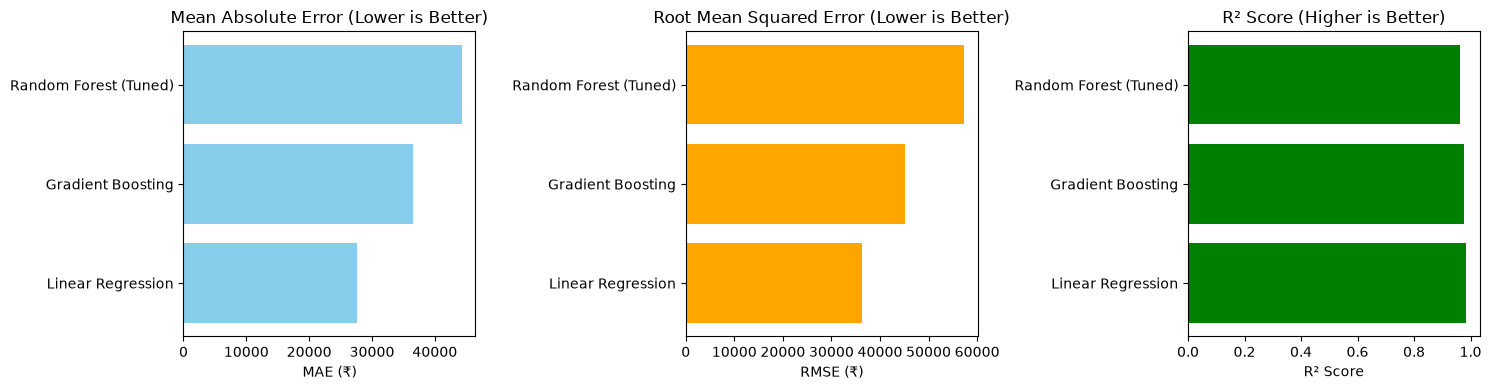

In [23]:
# --- Visualization 1: Bar Chart Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MAE Comparison
axes[0].barh(final_df['Model'], final_df['MAE'], color='skyblue')
axes[0].set_xlabel('MAE (₹)')
axes[0].set_title('Mean Absolute Error (Lower is Better)')

# RMSE Comparison
axes[1].barh(final_df['Model'], final_df['RMSE'], color='orange')
axes[1].set_xlabel('RMSE (₹)')
axes[1].set_title('Root Mean Squared Error (Lower is Better)')

# R² Comparison
axes[2].barh(final_df['Model'], final_df['R²'], color='green')
axes[2].set_xlabel('R² Score')
axes[2].set_title('R² Score (Higher is Better)')

plt.tight_layout()
plt.show()


Best Model: Linear Regression


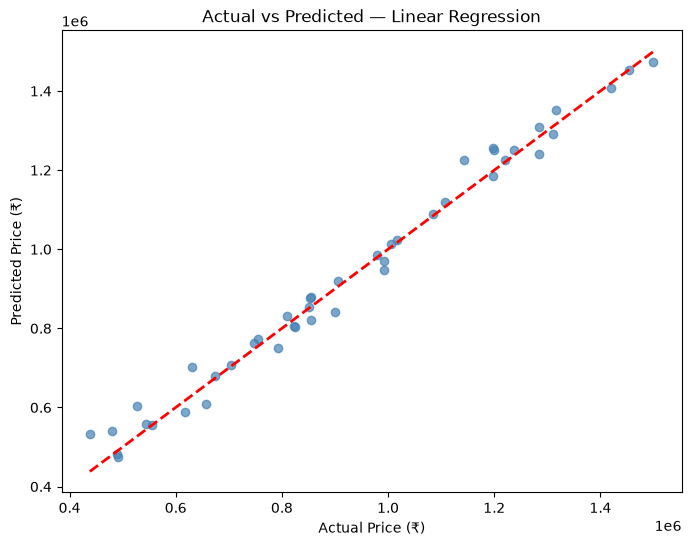

In [24]:
# --- Visualization 2: Actual vs Predicted for Best Model ---
best_model_name = final_df.iloc[0]['Model']
print(f"\nBest Model: {best_model_name}")

if best_model_name == 'Random Forest (Tuned)':
    best_pred = grid.predict(X_test)
else:
    best_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', final_models[best_model_name])
    ])
    best_pipe.fit(X_train, y_train)
    best_pred = best_pipe.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.7, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.show()

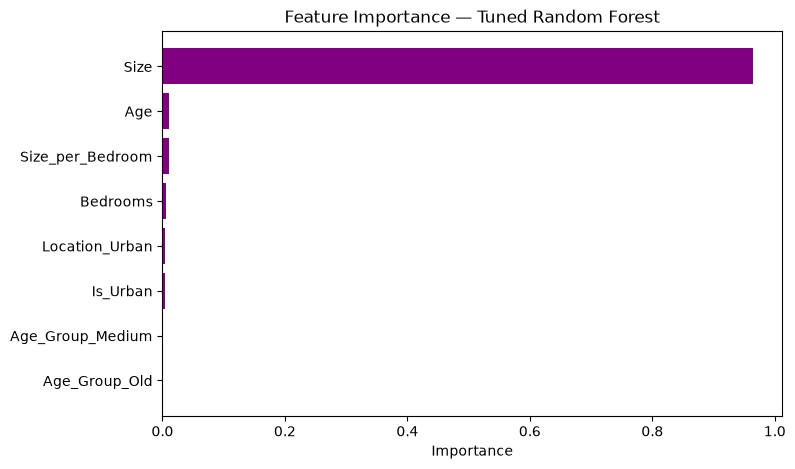

In [25]:
# --- Visualization 3: Feature Importance (Random Forest) ---
if 'Random Forest (Tuned)' in final_models:
    rf_model = grid.best_estimator_.named_steps['model']
    feature_names = X.columns
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(8, 5))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='purple')
    plt.xlabel('Importance')
    plt.title('Feature Importance — Tuned Random Forest')
    plt.show()

In [30]:
#Classifcation (Simple baseline)

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, 
    classification_report, RocCurveDisplay
)

In [32]:
# 1. Load Data
churn = pd.read_csv("customer_churn.csv")

# 2. Prepare Features and Target
X = churn.drop(columns=['Churn'])
y = churn['Churn']

# 3. Define Preprocessing
num_cols = ['MonthlyCharges', 'Tenure', 'SupportCalls']
cat_cols = ['ContractType', 'PaymentMethod']

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

In [33]:
# 4. Split Data (Stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 5. Build Baseline Model
baseline_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

baseline_pipe.fit(X_train, y_train)

# 6. Predict
y_pred = baseline_pipe.predict(X_test)
y_prob = baseline_pipe.predict_proba(X_test)[:, 1]
# 7. Evaluate
print("--- Baseline Logistic Regression ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

--- Baseline Logistic Regression ---
Accuracy : 0.7667
Precision: 0.7143
Recall   : 0.6522
F1-Score : 0.6818
ROC-AUC  : 0.8082


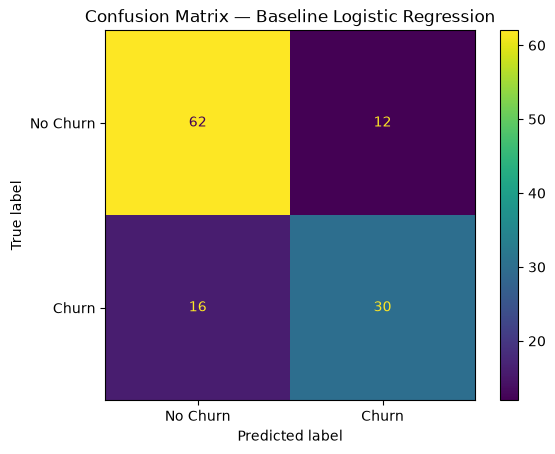

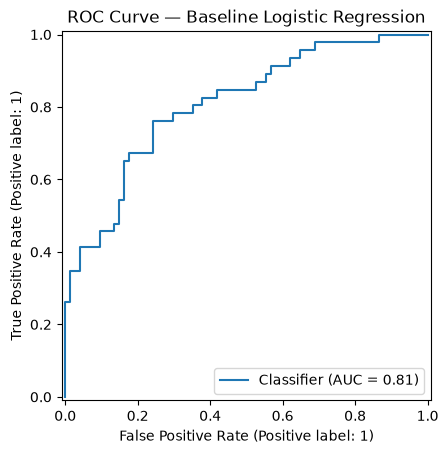

In [34]:
# 8. Visualize
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Churn', 'Churn'])
plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve — Baseline Logistic Regression")
plt.show()

In [39]:
# compare advanced model

In [37]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Define models to compare
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42)
}

# Try XGBoost if available
try:
    from xgboost import XGBClassifier
    classifiers['XGBoost'] = XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3, 
        subsample=0.8, colsample_bytree=0.8, 
        random_state=42, use_label_encoder=False, eval_metric='logloss'
    )
    print("XGBoost added to comparison.")
except ImportError:
    print("XGBoost not installed. Skipping.")

XGBoost not installed. Skipping.


In [38]:
# Train and evaluate each model
results = []

for name, model in classifiers.items():
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, pred, zero_division=0), 4),
        'F1': round(f1_score(y_test, pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, prob), 4)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\n--- Classification Model Comparison ---")
display(results_df)


--- Classification Model Comparison ---


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7667,0.7143,0.6522,0.6818,0.8082
2,Random Forest,0.7667,0.7647,0.5652,0.6500,0.7974
3,Gradient Boosting,0.7417,0.7027,0.5652,0.6265,0.7897
1,Decision Tree,0.7333,0.6944,0.5435,0.6098,0.7233


In [40]:
from sklearn.model_selection import cross_val_score

# Select best two models for cross-validation
best_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42)
}

print("--- 5-Fold Cross-Validation (ROC-AUC) ---")

for name, model in best_models.items():
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])
    
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc')
    
    print(f"\n{name}:")
    print(f"  Fold Scores: {np.round(cv_scores, 4)}")
    print(f"  Mean ROC-AUC: {cv_scores.mean():.4f}")
    print(f"  Std ROC-AUC : {cv_scores.std():.4f}")

--- 5-Fold Cross-Validation (ROC-AUC) ---

Logistic Regression:
  Fold Scores: [0.7875 0.7623 0.7808 0.8431 0.8525]
  Mean ROC-AUC: 0.8053
  Std ROC-AUC : 0.0358

Gradient Boosting:
  Fold Scores: [0.7843 0.7074 0.7262 0.8243 0.8287]
  Mean ROC-AUC: 0.7742
  Std ROC-AUC : 0.0497


In [41]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Gradient Boosting (best performer)
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1]
}

# Create pipeline
gb_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', GradientBoostingClassifier(random_state=42))
])

# Grid Search
grid = GridSearchCV(
    estimator=gb_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\n--- GridSearchCV Results ---")
print(f"Best Parameters: {grid.best_params_}")
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

--- GridSearchCV Results ---
Best Parameters: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 300}
Best CV ROC-AUC: 0.7624


In [42]:

# Evaluate tuned model on test set
tuned_pred = grid.predict(X_test)
tuned_prob = grid.predict_proba(X_test)[:, 1]

print(f"\nTuned Gradient Boosting Test Performance:")
print(f"  Accuracy : {accuracy_score(y_test, tuned_pred):.4f}")
print(f"  Precision: {precision_score(y_test, tuned_pred, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, tuned_pred, zero_division=0):.4f}")
print(f"  F1-Score : {f1_score(y_test, tuned_pred, zero_division=0):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, tuned_prob):.4f}")


Tuned Gradient Boosting Test Performance:
  Accuracy : 0.7667
  Precision: 0.7368
  Recall   : 0.6087
  F1-Score : 0.6667
  ROC-AUC  : 0.8060


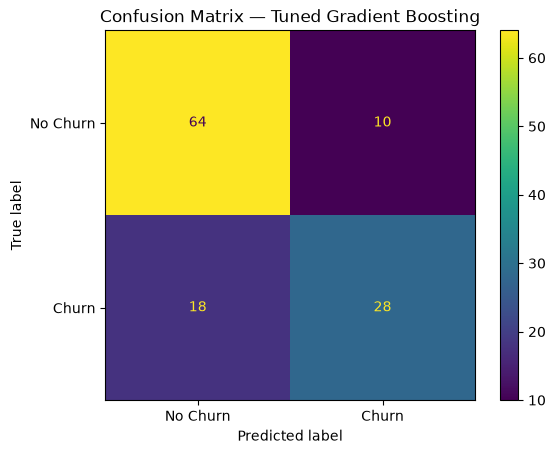

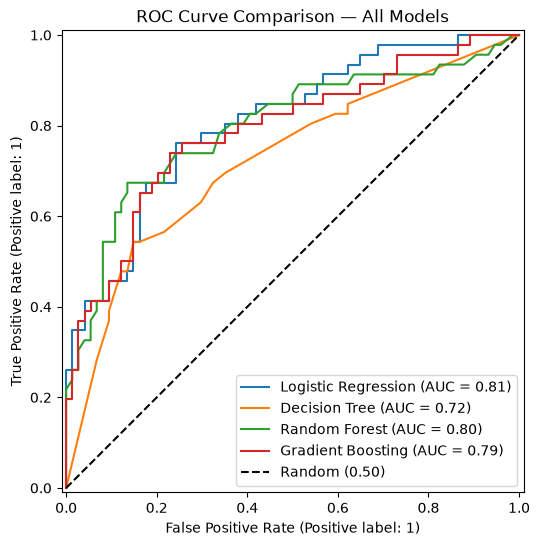

In [43]:
# Confusion Matrix for Tuned Model
ConfusionMatrixDisplay.from_predictions(y_test, tuned_pred, display_labels=['No Churn', 'Churn'])
plt.title("Confusion Matrix — Tuned Gradient Boosting")
plt.show()

# ROC Curve Comparison for All Models
plt.figure(figsize=(8, 6))

for name, model in classifiers.items():
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=plt.gca())

plt.title('ROC Curve Comparison — All Models')
plt.plot([0, 1], [0, 1], 'k--', label='Random (0.50)')
plt.legend()
plt.show()

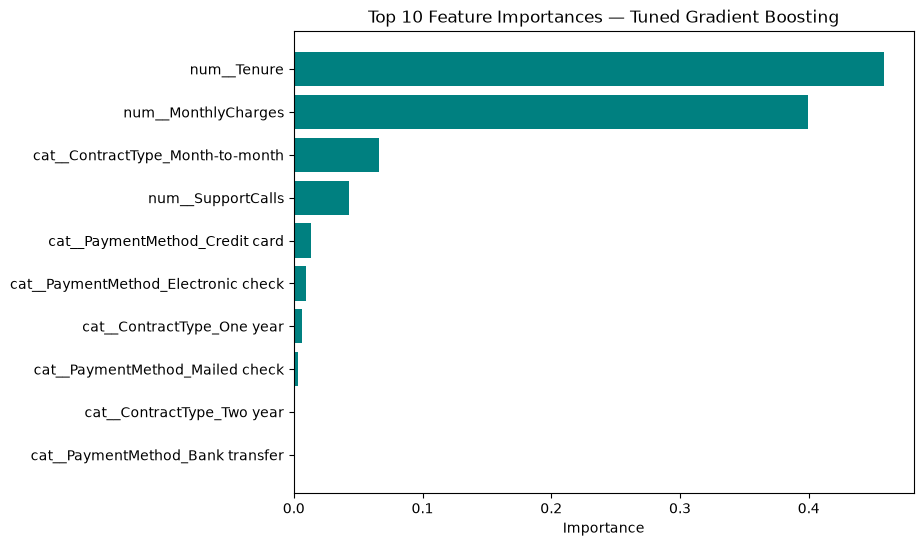

In [44]:
# Feature Importance from Tuned Gradient Boosting
gb_model = grid.best_estimator_.named_steps['model']
feature_names = grid.best_estimator_.named_steps['preprocess'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances — Tuned Gradient Boosting')
plt.show()

In [45]:
# Final comparison of all models including tuned model
final_results = []

for name, model in classifiers.items():
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]
    
    final_results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, pred, zero_division=0), 4),
        'F1': round(f1_score(y_test, pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, prob), 4)
    })

In [46]:
# Add tuned model
final_results.append({
    'Model': 'Tuned Gradient Boosting',
    'Accuracy': round(accuracy_score(y_test, tuned_pred), 4),
    'Precision': round(precision_score(y_test, tuned_pred, zero_division=0), 4),
    'Recall': round(recall_score(y_test, tuned_pred, zero_division=0), 4),
    'F1': round(f1_score(y_test, tuned_pred, zero_division=0), 4),
    'ROC-AUC': round(roc_auc_score(y_test, tuned_prob), 4)
})

final_df = pd.DataFrame(final_results).sort_values('ROC-AUC', ascending=False)
print("\n--- Final Classification Model Comparison ---")
display(final_df)


--- Final Classification Model Comparison ---


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7667,0.7143,0.6522,0.6818,0.8082
4,Tuned Gradient Boosting,0.7667,0.7368,0.6087,0.6667,0.8060
2,Random Forest,0.7667,0.7647,0.5652,0.6500,0.7974
3,Gradient Boosting,0.7417,0.7027,0.5652,0.6265,0.7897
1,Decision Tree,0.7333,0.6944,0.5435,0.6098,0.7233
